##                                   LAZYPREDICT

In [1]:
# Example 3.27 - PyCaret Alternative for Google Colab
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Load Dataset Iris
iris = datasets.load_iris(as_frame=True)
X, y = iris.data, iris.target

print("--- 5 Data Pertama ---")
print(X.head())
print("\n--- Membandingkan Model (Seperti PyCaret) ---")

# 2. Daftar Algoritma Klasifikasi
models = {
    'Random Forest': RandomForestClassifier(random_state=123),
    'Gradient Boosting': GradientBoostingClassifier(random_state=123),
    'Extra Trees': ExtraTreesClassifier(random_state=123),
    'SVM': SVC(),
    'Logistic Regression': LogisticRegression(max_iter=200),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=123)
}

# 3. Evaluasi Performa Setiap Model (Cross Validation)
results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    results.append({
        'Model': name,
        'Accuracy': scores.mean(),
        'Std Dev': scores.std()
    })

# 4. Tampilkan Tabel Peringkat Model Terbaik
df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print(df_results.to_string(index=False))

--- 5 Data Pertama ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

--- Membandingkan Model (Seperti PyCaret) ---
              Model  Accuracy  Std Dev
Logistic Regression  0.973333 0.024944
K-Nearest Neighbors  0.973333 0.024944
                SVM  0.966667 0.021082
  Gradient Boosting  0.960000 0.032660
      Decision Tree  0.960000 0.032660
      Random Forest  0.960000 0.024944
        Extra Trees  0.953333 0.033993


In [2]:
pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.5 MB/s eta 0:00:00


In [4]:
import lazypredict
from lazypredict.Supervised import LazyClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True)

# Perbaikan di baris ini: test_size=.25
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

clf = LazyClassifier()
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
LabelPropagation               1.000000           1.000000  1.000000   
LinearDiscriminantAnalysis     1.000000           1.000000  1.000000   
LabelSpreading                 1.000000           1.000000  1.000000   
QuadraticDiscriminantAnalysis  1.000000           1.000000  1.000000   
GaussianNB                     0.973684           0.979167  1.000000   
ExtraTreesClassifier           0.973684           0.979167  1.000000   
ExtraTreeClassifier            0.973684           0.979167  0.982759   
KNeighborsClassifier           0.973684           0.979167  0.998948   
DecisionTreeClassifier         0.973684           0.979167  0.982759   
BaggingClassifier              0.973684           0.979167  1.000000   
AdaBoostClassifier             0.973684           0.979167  0.973932   
SVC                            0.973684           0.979167      

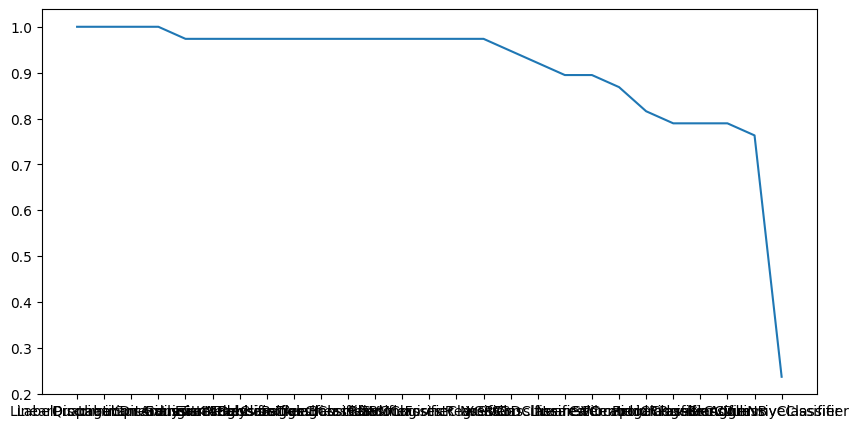

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(models.index, models['Accuracy'])

In [7]:
import lazypredict
from lazypredict.Supervised import LazyRegressor
from sklearn import datasets
from sklearn.utils import shuffle
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split  # Import tambahkan di sini

# 1. Load dataset
X, y = fetch_california_housing(return_X_y=True, as_frame=True)

# 2. Split data (perbaikan syntax pada test_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1)

# 3. Jalankan LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

print(models)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


                               Adjusted R-Squared    R-Squared       RMSE  \
Model                                                                       
XGBRegressor                             0.835667     0.836305   0.469177   
LGBMRegressor                            0.832418     0.833068   0.473793   
HistGradientBoostingRegressor            0.828649     0.829313   0.479092   
RandomForestRegressor                    0.812115     0.812844   0.501673   
ExtraTreesRegressor                      0.809712     0.810450   0.504871   
BaggingRegressor                         0.799337     0.800115   0.518452   
MLPRegressor                             0.783910     0.784748   0.538012   
GradientBoostingRegressor                0.781889     0.782734   0.540523   
NuSVR                                    0.745389     0.746376   0.584001   
SVR                                      0.743362     0.744357   0.586321   
KNeighborsRegressor                      0.690845     0.692043   0.643522   

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


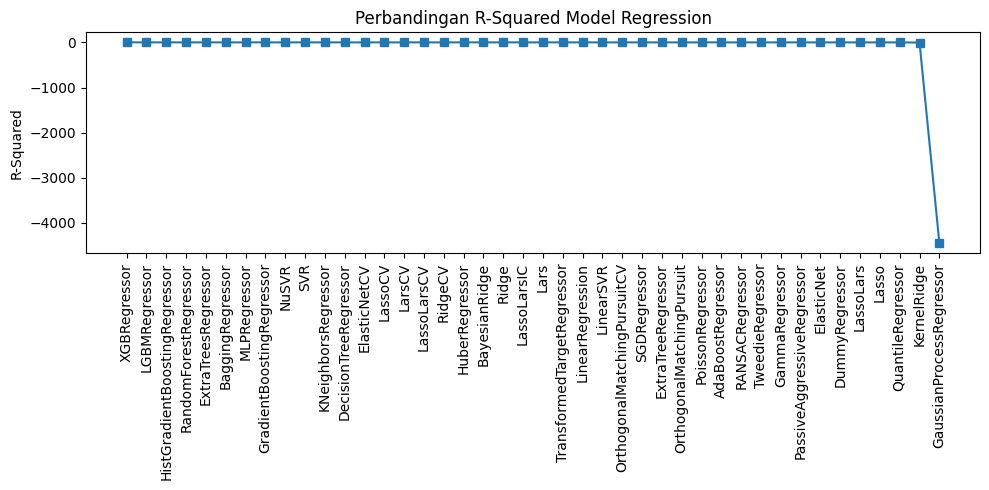

In [9]:
import matplotlib.pyplot as plt

# Perbaikan 1: Gunakan 'R-Squared' (tanpa spasi setelah tanda minus)
# Perbaikan 2: Format linestyle '-s' (tanpa spasi)
plt.figure(figsize=(10, 5))
plt.plot(models.index, models['R-Squared'], '-s')

plt.xticks(rotation=90)  # Memutar nama model agar tidak bertumpuk
plt.ylabel('R-Squared')
plt.title('Perbandingan R-Squared Model Regression')
plt.tight_layout()
plt.show()